In [3]:
%pip install yfinance

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------- -------------- 1.0/1.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.3 MB/s eta 0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import yfinance as yf

In [6]:
%pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 6.7 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.2 MB 4.4 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 4.4 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.2 MB 4.4 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.2 MB 4.9 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 4.9 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -------- ---------------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[*********************100%***********************]  1 of 1 completed


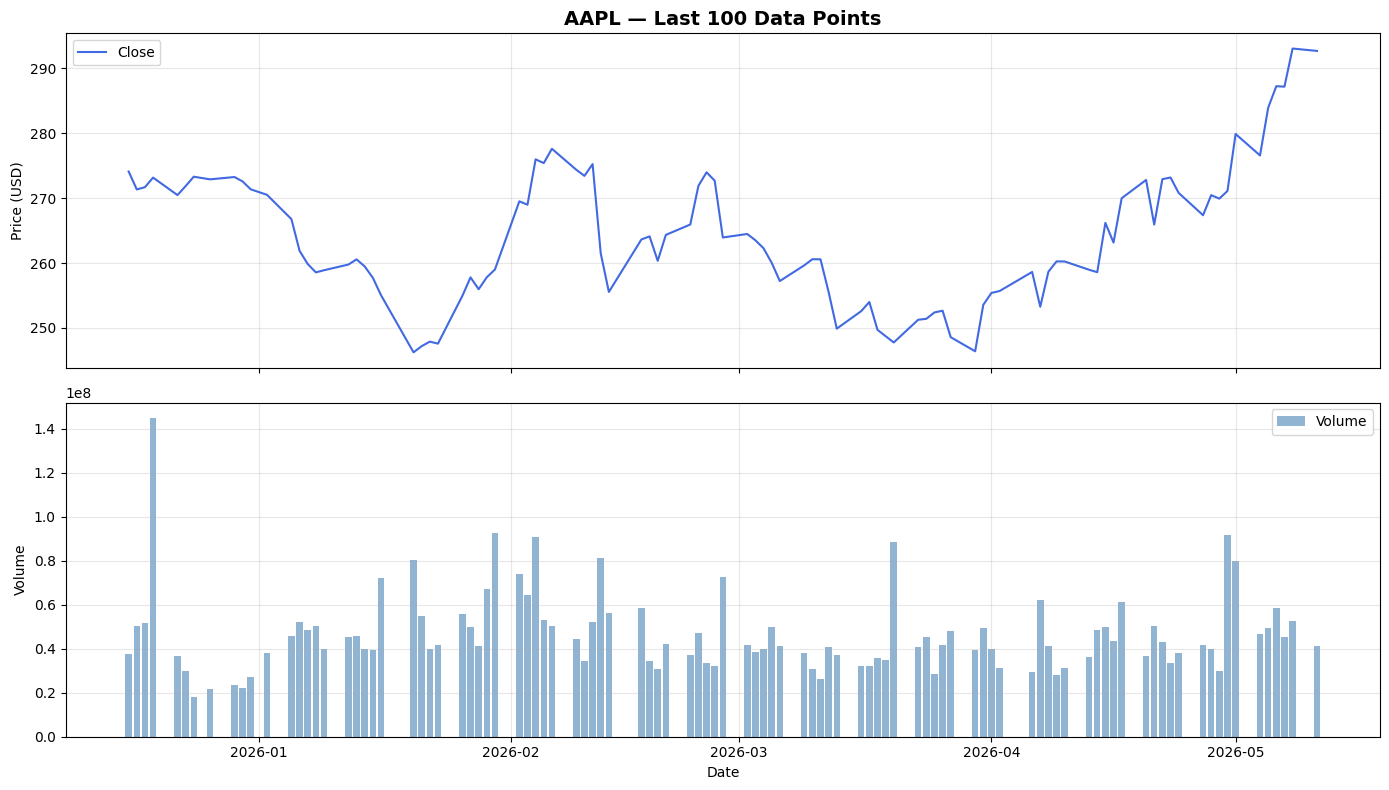

In [9]:
import matplotlib.pyplot as plt

ticker = "AAPL"
df = yf.download(ticker, period="6mo", auto_adjust=True)

# yfinance returns MultiIndex columns — flatten to single level
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep exactly the last 100 trading-day data points
df = df.tail(100)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["Close"], color="royalblue", linewidth=1.5, label="Close")
axes[0].set_title(f"{ticker} — Last 100 Data Points", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(df.index, df["Volume"].values, color="steelblue", alpha=0.6, label="Volume")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print(f"Stock: {ticker}  |  Rows: {len(df)}  |  Date range: {df.index[0].date()} → {df.index[-1].date()}\n")
print(df.to_string())

Stock: AAPL  |  Rows: 100  |  Date range: 2025-12-16 → 2026-05-11

Price            Close        High         Low        Open     Volume
Date                                                                 
2025-12-16  274.100739  274.989103  271.285991  272.314080   37648600
2025-12-17  271.335876  275.647872  271.136266  274.500011   50138700
2025-12-18  271.685242  273.122574  266.454969  273.102591   51630700
2025-12-19  273.162506  274.090774  269.399478  271.645305  144632000
2025-12-22  270.467499  273.372106  270.008360  272.353978   36571800
2025-12-23  271.854919  271.994674  269.060124  270.337749   29642000
2025-12-24  273.302216  274.919206  271.695216  271.834940   17910600
2025-12-26  272.892975  274.859323  272.353968  273.651575   21521800
2025-12-29  273.252350  273.851213  271.844961  272.184327   23715200
2025-12-30  272.573578  273.571723  271.775074  272.304090   22139600
2025-12-31  271.355835  273.172467  271.246054  272.553622   27293600
2026-01-02  270.507416 